# Project 2: Student Exam Performance

**Objective**: Explore what factors affect student exam scores, then verify findings with statistical tests.

**Type**: Exploratory Data Analysis (EDA) + Confirmatory Data Analysis (CDA)

**Dataset**: `StudentPerformanceFactors.csv` — 6,607 students, 20 columns covering academic, lifestyle, and socioeconomic factors. Target variable: `Exam_Score`.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', None)
np.random.seed(42)

TARGET = 'Exam_Score'

## 1. Load & Validate

In [3]:
df = pd.read_csv('StudentPerformanceFactors.csv')
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 2. Univariate Analysis

### Target variable: Exam Score

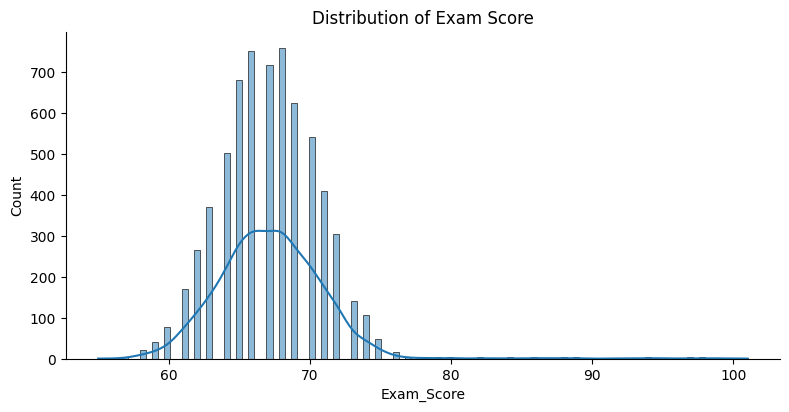

In [6]:
sns.displot(df, x=TARGET, kde=True, height=4, aspect=2)
plt.title('Distribution of Exam Score')
plt.show()

### Numerical features (small multiples)

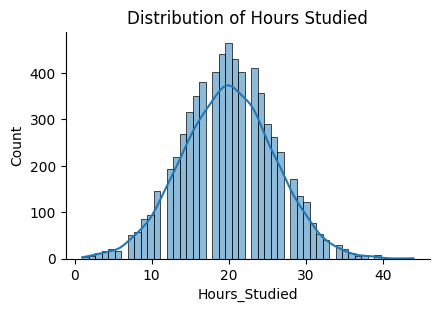

In [7]:
sns.displot(
    df, x='Hours_Studied',
    kde=True, height=3, aspect=1.5
)
plt.title('Distribution of Hours Studied')
plt.show()

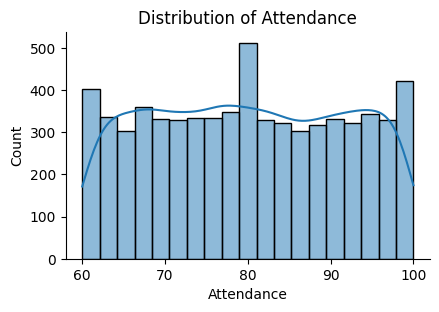

In [8]:
sns.displot(
    df, x='Attendance',
    kde=True, height=3, aspect=1.5
)
plt.title('Distribution of Attendance')
plt.show()

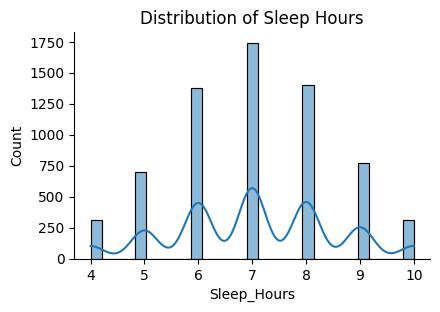

In [4]:
sns.displot(
    df, x='Sleep_Hours',
    kde=True, height=3, aspect=1.5
)
plt.title('Distribution of Sleep Hours')
plt.show()

### Categorical features

In [9]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    print(f'{col}:\n{df[col].value_counts()}\n')

Parental_Involvement:
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities:
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access:
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income:
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality:
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

School_Type:
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities:
Learning_Disabilities
No     5912
Yes     695
Name: c

## 3. Bivariate Analysis

### Initial assumptions before testing:
- Students who study more hours score higher
- Higher attendance leads to better scores
- School type affects performance
- Parental involvement level affects performance
- Motivation level affects performance

### Numerical features vs Exam Score (small multiples)

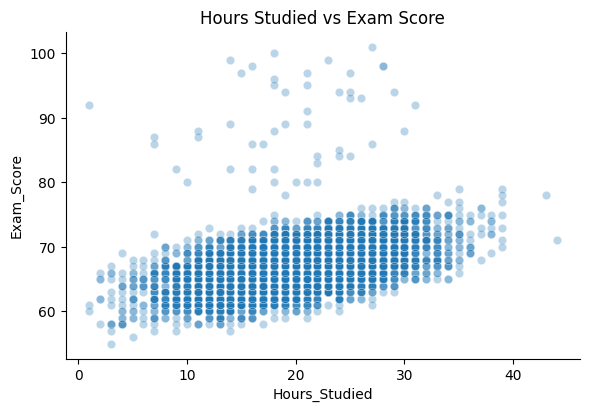

In [10]:
# Hours Studied vs Exam Score
sns.relplot(
    data=df, x='Hours_Studied', y=TARGET,
    alpha=0.3, height=4, aspect=1.5
)
plt.title('Hours Studied vs Exam Score')
plt.show()

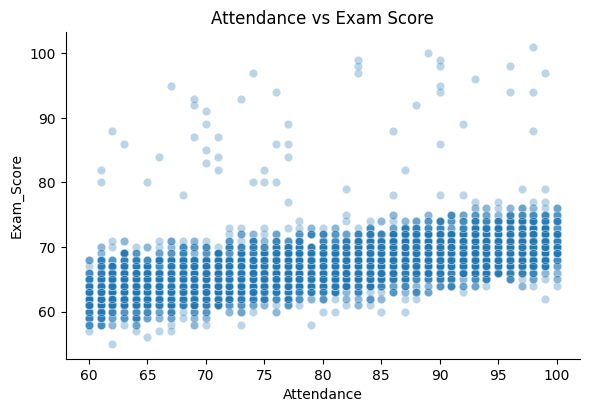

In [11]:
# Attendance vs Exam Score
sns.relplot(
    data=df, x='Attendance', y=TARGET,
    alpha=0.3, height=4, aspect=1.5
)
plt.title('Attendance vs Exam Score')
plt.show()

### Categorical features vs Exam Score (small multiples)

C:\Users\MA\AppData\Local\Temp\ipykernel_20992\1143404361.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


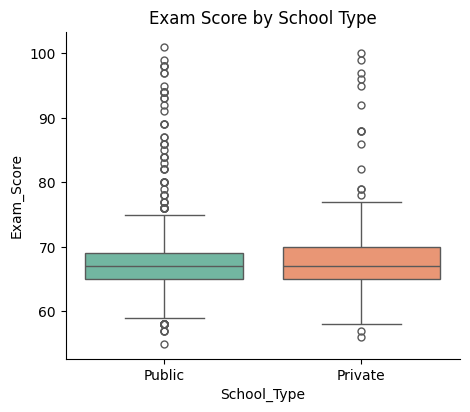

,count,mean,std,min,25%,50%,75%,max
School_Type,,,,,,,,
Private,2009.0,67.29,3.85,56.0,65.0,67.0,70.0,100.0
Public,4598.0,67.21,3.91,55.0,65.0,67.0,69.0,101.0


In [12]:
# School Type vs Exam Score
sns.catplot(
    data=df, x='School_Type', y=TARGET,
    kind='box', palette='Set2', height=4, aspect=1.2
)
plt.title('Exam Score by School Type')
plt.show()

df.groupby('School_Type')[TARGET].describe().round(2)

C:\Users\MA\AppData\Local\Temp\ipykernel_20992\1902619135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


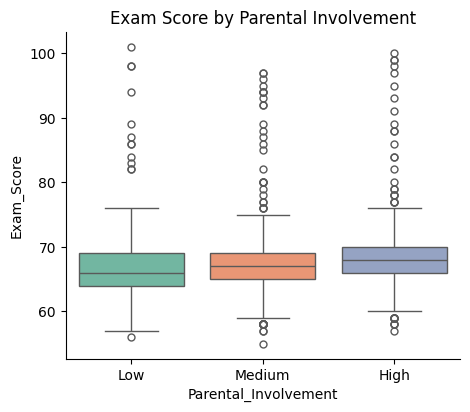

,count,mean,std,min,25%,50%,75%,max
Parental_Involvement,,,,,,,,
High,1908.0,68.09,3.95,57.0,66.0,68.0,70.0,100.0
Low,1337.0,66.36,3.97,56.0,64.0,66.0,69.0,101.0
Medium,3362.0,67.10,3.73,55.0,65.0,67.0,69.0,97.0


In [13]:
# Parental Involvement vs Exam Score
sns.catplot(
    data=df, x='Parental_Involvement', y=TARGET,
    order=['Low', 'Medium', 'High'],
    kind='box', palette='Set2', height=4, aspect=1.2
)
plt.title('Exam Score by Parental Involvement')
plt.show()

df.groupby('Parental_Involvement')[TARGET].describe().round(2)

C:\Users\MA\AppData\Local\Temp\ipykernel_20992\3262447941.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


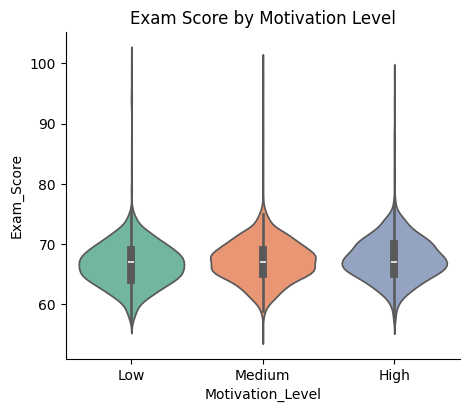

,count,mean,std,min,25%,50%,75%,max
Motivation_Level,,,,,,,,
High,1319.0,67.70,3.88,57.0,65.0,67.0,70.0,98.0
Low,1937.0,66.75,3.96,57.0,64.0,67.0,69.0,101.0
Medium,3351.0,67.33,3.83,55.0,65.0,67.0,69.0,100.0


In [14]:
# Motivation Level vs Exam Score
sns.catplot(
    data=df, x='Motivation_Level', y=TARGET,
    order=['Low', 'Medium', 'High'],
    kind='violin', palette='Set2', height=4, aspect=1.2
)
plt.title('Exam Score by Motivation Level')
plt.show()

df.groupby('Motivation_Level')[TARGET].describe().round(2)

## 4. Hypothesis Testing

**alpha** = 0.05

### H1: School Type affects Exam Score

2 independent groups → `ttest_ind()`

In [5]:
alpha = 0.05

public  = df.loc[df['School_Type'] == 'Public',  TARGET]
private = df.loc[df['School_Type'] == 'Private', TARGET]

t_stat, p_value = stats.ttest_ind(public, private)

print(f't-statistic: {t_stat}')
print(f'p-value: {p_value}')

if p_value <= alpha:
    print('Conclusion: School type significantly affects exam scores')
else:
    print('Conclusion: No significant difference between school types')

t-statistic: -0.7187537041931684
p-value: 0.4723181126217438
Conclusion: No significant difference between school types


### H2: Parental Involvement level affects Exam Score

3 groups → Tukey HSD post-hoc to find which pairs differ

In [17]:
tukey = pairwise_tukeyhsd(
    endog=df[TARGET],
    groups=df['Parental_Involvement'],
    alpha=0.05
)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.7345   0.0 -2.0557 -1.4133   True
  High Medium  -0.9946   0.0 -1.2528 -0.7364   True
   Low Medium   0.7399   0.0  0.4487  1.0311   True
---------------------------------------------------


### H3: Motivation Level affects Exam Score

3 groups → Tukey HSD

In [18]:
tukey_motiv = pairwise_tukeyhsd(
    endog=df[TARGET],
    groups=df['Motivation_Level'],
    alpha=0.05
)
print(tukey_motiv)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low  -0.9521    0.0 -1.2765 -0.6278   True
  High Medium  -0.3737 0.0085  -0.669 -0.0783   True
   Low Medium   0.5785    0.0  0.3191  0.8378   True
----------------------------------------------------


## 5. Summary & Insights

### Hypothesis Testing Results

| # | Hypothesis | Result | Numbers |
|---|---|---|---|
| H1 | School type affects scores | **Not Confirmed** | t=-0.72, p=0.47 |
| H2 | Parental involvement affects scores | **Confirmed** | All pairs significant (p<0.05) |
| H3 | Motivation level affects scores | **Confirmed** | All pairs significant (p<0.05) |

### 7 Insights

1. **Study hours is the strongest driver of exam performance** — the scatter plot shows a clear positive trend: the more a student studies, the higher their score.

2. **Attendance is positively associated with exam scores** — students with higher attendance rates consistently score better, confirming that showing up matters.

3. **School type does NOT significantly affect scores** — despite what we assumed, Private (mean=67.29) vs Public (mean=67.21) showed no meaningful difference (t=-0.72, p=0.47). This assumption was rejected.

4. **Parental involvement significantly affects scores** — Tukey HSD confirmed all three pairs differ. High involvement averages 68.09, Medium 67.10, Low 66.36. Higher involvement = better outcomes.

5. **Motivation level significantly affects scores** — High motivation students average 67.70 vs Low at 66.75. All pairs were statistically significant (p<0.05), confirming motivation plays a real role.

6. **Teacher quality has 78 missing values** — the only column with missing data, which should be handled before any analysis involving that variable.

7. **Most students have Medium parental involvement (3,362) and Medium access to resources (3,319)** — the dataset is skewed toward middle categories, meaning extreme groups (High/Low) are smaller and conclusions about them should be made with caution.

**Future work**: Handle missing Teacher_Quality values and test whether teacher quality affects scores; build a regression model to rank each factor by its predictive power.
